# Input Data

## Import Libraries


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
df.head()
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
# test_data.head()

In [3]:
df.info()
# df.shape
# print(list(df_categorical.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# EDA

In [4]:
# Filter out categorical features
df_categorical = df[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df.nunique()
unique_values = df.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,88,"[22.0, 38.0, 26.0, 35.0, nan, 54.0, 2.0, 27.0,..."
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


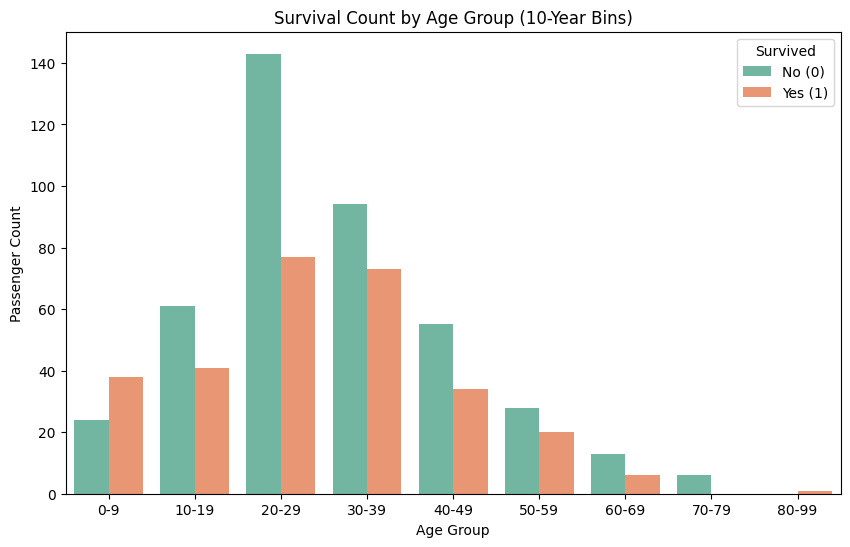

In [5]:
# ✅ 1️⃣ 创建年龄分组（以 10 岁为间隔）
# Create Age Bins every 10 years
df_eda = df.copy()
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', 
          '50-59', '60-69', '70-79', '80-99']

df_eda['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# ✅ 2️⃣ 创建分组后的柱状图
# Plot survival counts per age group
plt.figure(figsize=(10,6))
sns.countplot(data=df_eda, x='AgeGroup', hue='Survived', palette='Set2', dodge=True)
plt.title("Survival Count by Age Group (10-Year Bins)")
plt.xlabel("Age Group")
plt.ylabel("Passenger Count")
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

In [6]:
# # ✅ 只筛选出存活的乘客
# # Filter only passengers who survived
# survived_df = df[df['Survived'] == 1].copy()

# # ✅ 分组柱状图：按年龄段 + 舱位等级
# # Countplot by AgeGroup and Pclass (only for survivors)
# plt.figure(figsize=(10,6))
# sns.countplot(data=survived_df, x='AgeGroup', hue='Pclass', palette='Set3')
# plt.title("Survivors by Age Group and Passenger Class")
# plt.xlabel("Age Group (10-Year Bins)")
# plt.ylabel("Survivor Count")
# plt.legend(title='Pclass')
# plt.show()

# Data Pre-processing


## Dataset Overview

In [7]:
df_categorical = df[['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']].astype(str)
df_numerical = df.drop(df_categorical.columns.tolist() + ['PassengerId'], axis=1)

## Numerical Variables Univariate Analysis

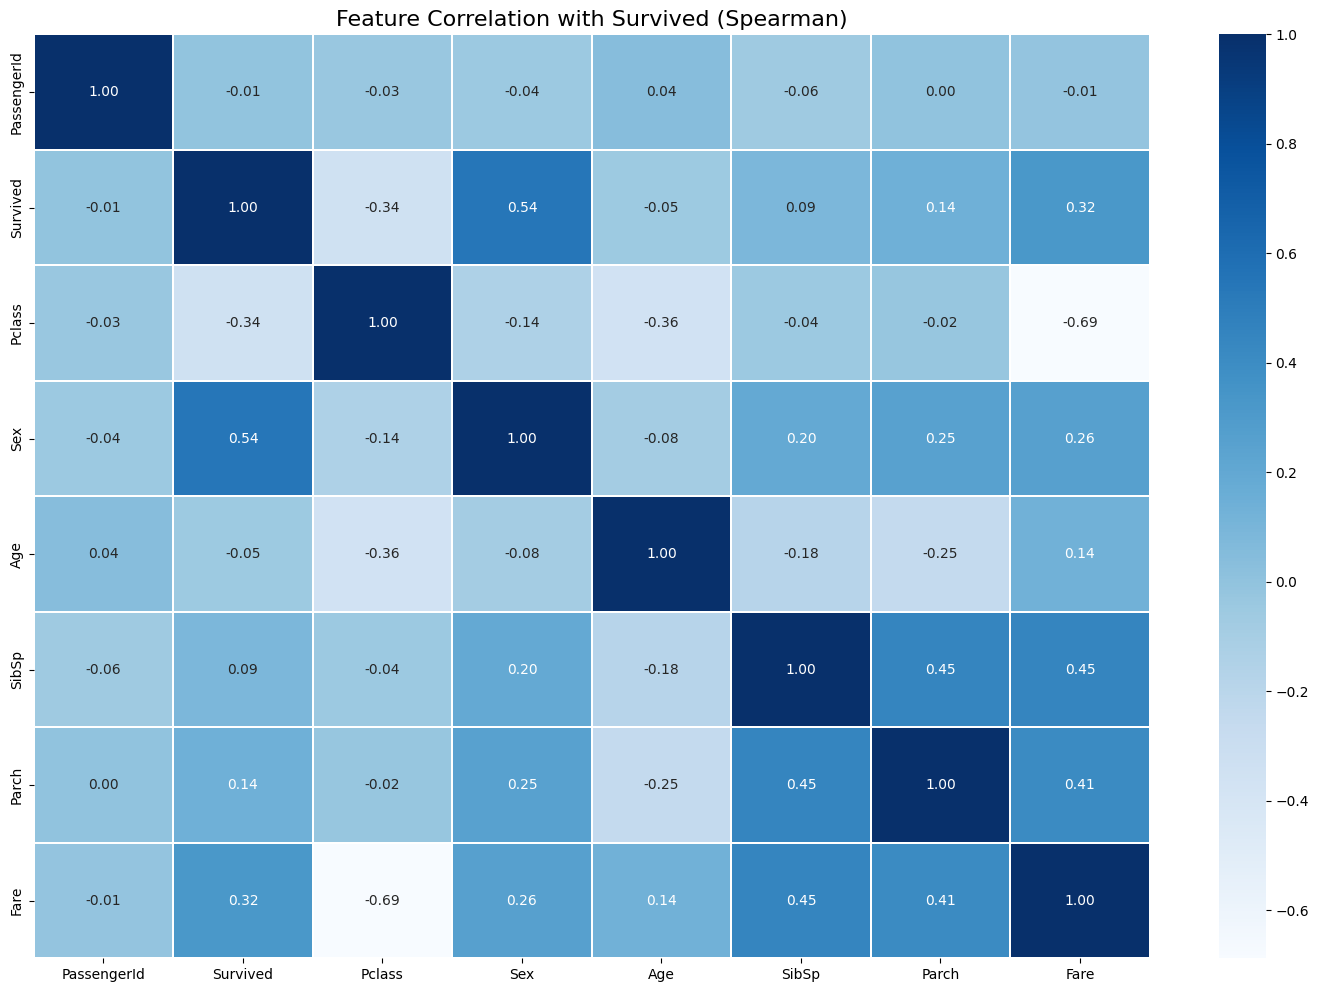

In [8]:
df_corr = df.copy()

# # 检查 Sex 列值
# print(df_corr['Sex'].unique())  # output ['male' 'female']

# 把 'male' / 'female' 转为 0 / 1
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})

# 处理 Embarked 和 Ticket_Prefix（如果有）
df_corr['Ticket_Prefix'] = df_corr['Ticket'].apply(lambda x: x.split()[0] if not x.isdigit() else 'NONE')
df_corr = pd.get_dummies(df_corr, columns=['Embarked', 'Ticket_Prefix'], drop_first=True)

# 删除无关的字符串列（Name, Ticket, Cabin）
df_corr = df_corr.drop(columns=['Name', 'Ticket', 'Cabin'], errors='ignore')

# 保留数值列
df_corr = df_corr.select_dtypes(include=[np.number])

# 计算相关性
corr = df_corr.corr(method='spearman')

# mask = np.zeros_like(corr, dtype=bool)
# mask[np.triu_indices_from(mask)] = True

# 画热力图
plt.figure(figsize=(18, 12))
sns.heatmap(corr, 
            # mask=mask, 
            annot=True, cmap='Blues', fmt='.2f', linewidths=0.2)
plt.title('Feature Correlation with Survived (Spearman)', fontsize=16)
plt.show()


## Check NaN Value

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Impute missing values

In [10]:
# 复制一份原始数据，避免修改原始 df
df01 = df.copy()
test_data01 = test_data.copy()

In [11]:
# ✅ 处理 Cabin → 是否有舱位信息（0=无，1=有）
# Cabin: Convert to binary (0 = missing, 1 = present)
df01['Has_Cabin'] = df['Cabin'].notnull().astype(int)
test_data01['Has_Cabin'] = test_data01['Cabin'].notnull().astype(int)


# 将 Fare 分为 3 个等级：低、中、高
# Bin Fare into 3 levels: low, medium, high
df01['FareBin'] = pd.qcut(df01['Fare'], 3, labels=['Low', 'Medium', 'High'])
test_data01['FareBin'] = pd.qcut(test_data01['Fare'], 3, labels=['Low', 'Medium', 'High'])

# Group by Sex, Pclass, Parch, FareBin, Has_Cabin to get Age median
age_medians = df01.groupby(['Sex', 'Pclass', 'Parch', 'FareBin', 'Has_Cabin'])['Age'].median().to_dict()


def fill_age_with_group_median(row):
    if pd.notnull(row['Age']):
        return row['Age']
    
    key = (row['Sex'], row['Pclass'], row['Parch'], row['FareBin'], row['Has_Cabin'])
    
    # 先尝试从字典中取值
    median_value = age_medians.get(key)
    
    # 如果取不到，或取到的是 NaN，就用总体中位数
    if pd.isnull(median_value):
        return df01['Age'].median()
    else:
        return median_value

df01['Age'] = df01.apply(fill_age_with_group_median, axis=1)
test_data01['Age'] = test_data01.apply(fill_age_with_group_median, axis=1)


#  定义函数：将 Age 转换为按 10 岁分组的整数编号（0, 1, 2, ...）
# Define function to convert Age into 10-year bins: 0=0-9, 1=10-19, etc.
def age_to_category(age):
    if pd.isnull(age):
        return np.nan  # 若有缺失，保留为 NaN / Preserve missing
    else:
        return int(age // 10)  # 向下取整每10岁一个类



# 5️⃣ 应用该函数并覆盖 Age 列
# Apply the function to Age column
df01['Age'] = df01['Age'].apply(age_to_category)
test_data01['Age'] = test_data01['Age'].apply(age_to_category)



# 删除原始 Cabin 列（可选）
# Drop the original Cabin column
df01.drop(columns=['Cabin'], inplace=True)
test_data01.drop(columns=['Cabin'], inplace=True)

# ✅ 填补 Embarked 缺失值（用训练集众数填充到两个数据集）
# Embarked: Fill missing values using mode from training data
embarked_mode = df01['Embarked'].mode()[0]  # 众数 / Most frequent value
df01['Embarked'] = df01['Embarked'].fillna(embarked_mode)
test_data01['Embarked'] = test_data01['Embarked'].fillna(embarked_mode)


In [12]:
df01.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FareBin
0,1,0,3,"Braund, Mr. Owen Harris",male,2,1,0,A/5 21171,7.2500,S,0,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3,1,0,PC 17599,71.2833,C,1,High
2,3,1,3,"Heikkinen, Miss. Laina",female,2,0,0,STON/O2. 3101282,7.9250,S,0,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3,1,0,113803,53.1000,S,1,High
4,5,0,3,"Allen, Mr. William Henry",male,3,0,0,373450,8.0500,S,0,Low


In [13]:
# checking NaN value again
df01.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
FareBin        0
dtype: int64

In [14]:
# ✅ FamilySize
df01['FamilySize'] = df01['SibSp'] + df01['Parch'] + 1
test_data01['FamilySize'] = test_data01['SibSp'] + test_data01['Parch'] + 1

# ✅ IsAlone
df01['IsAlone'] = (df01['FamilySize'] == 1).astype(int)
test_data01['IsAlone'] = (test_data01['FamilySize'] == 1).astype(int)

# ✅ Title
df01['Title'] = df01['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_data01['Title'] = test_data01['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 简化 Title 列（统一稀有称呼）
for dataset in [df01, test_data01]:
    dataset['Title'] = dataset['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    dataset['Title'] = dataset['Title'].replace(['Mlle', 'Ms'], 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')


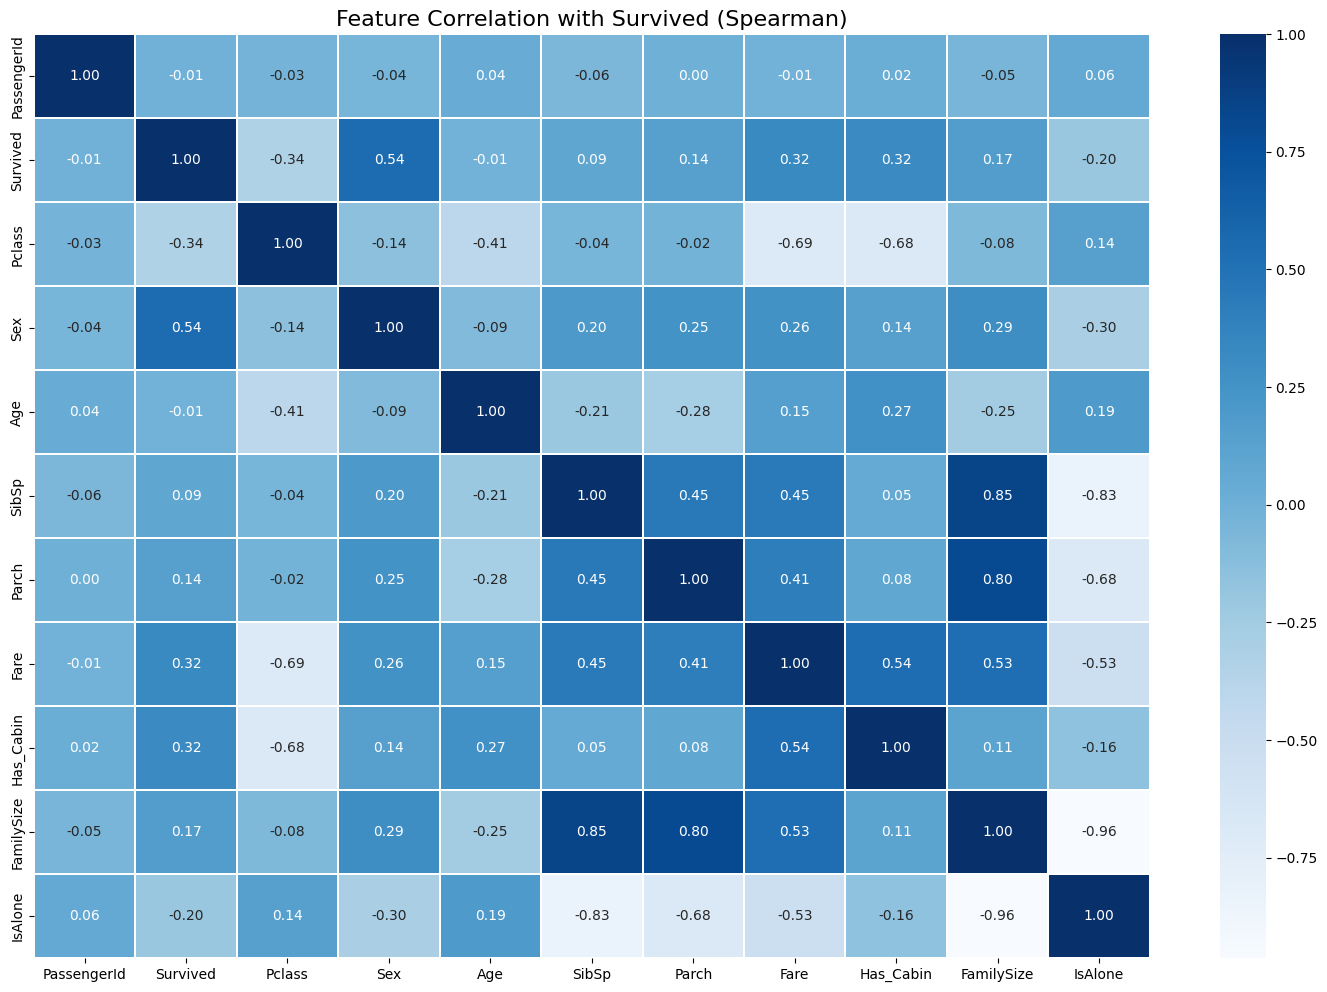

In [15]:
df_corr01 = df01.copy()

df_corr01['Sex'] = df_corr01['Sex'].map({'male': 0, 'female': 1})

# 处理 Embarked 和 Ticket_Prefix（如果有）
df_corr01['Ticket_Prefix'] = df_corr01['Ticket'].apply(lambda x: x.split()[0] if not x.isdigit() else 'NONE')
df_corr01 = pd.get_dummies(df_corr01, columns=['Embarked', 'Ticket_Prefix'], drop_first=True)

# 删除无关的字符串列（Name, Ticket, Cabin）以防万一
df_corr01 = df_corr01.drop(columns=['Name', 'Ticket'], errors='ignore')

# 保留数值列
df_corr01 = df_corr01.select_dtypes(include=[np.number])

# 计算相关性
corr01 = df_corr01.corr(method='spearman')

# 遮罩矩阵
mask = np.zeros_like(corr01, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 画热力图
plt.figure(figsize=(18, 12))
sns.heatmap(corr01, 
            # mask=mask, 
            annot=True, cmap='Blues', fmt='.2f', linewidths=0.2)
plt.title('Feature Correlation with Survived (Spearman)', fontsize=16)
plt.show()

In [16]:
# correlation = df01[['Age', 'Survived']].corr(method='spearman').loc['Age', 'Survived']
# print(f"Age & Survived  (Spearman Correlation): {correlation:.4f}")

In [17]:
# Filter out categorical features
df_categorical = df01[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df01.nunique()
unique_values = df01.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,9,"[2, 3, 5, 0, 1, 4, 6, 7, 8]"
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


In [18]:
# 提取 Ticket 的字母前缀（没有字母就标记为 'NONE'）
df01['Ticket_Prefix'] = df01['Ticket'].apply(lambda x: x.split()[0] if not x.isdigit() else 'NONE')
df01['Ticket_Prefix'] = df01['Ticket_Prefix'].str.upper()
# print(df01['Ticket_Prefix'].value_counts())

# 创建 Ticket_Prefix 列：从 Ticket 字符串中提取前缀
def extract_ticket_prefix(ticket):
    return ticket.split()[0] if not ticket.isdigit() else 'NONE'

df01['Ticket_Prefix'] = df01['Ticket'].apply(extract_ticket_prefix)
test_data01['Ticket_Prefix'] = test_data01['Ticket'].apply(extract_ticket_prefix)


In [19]:
# Filter out categorical features
df_categorical = df01[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']].astype(str)

# Calculate number of unique values and unique values for each feature
unique_counts = df01.nunique()
unique_values = df01.apply(lambda x: x.unique())

# Create new dataframe with the results  
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
PassengerId,891,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
Survived,2,"[0, 1]"
Pclass,3,"[3, 1, 2]"
Name,891,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,2,"[male, female]"
Age,9,"[2, 3, 5, 0, 1, 4, 6, 7, 8]"
SibSp,7,"[1, 0, 3, 4, 2, 5, 8]"
Parch,7,"[0, 1, 2, 5, 3, 4, 6]"
Ticket,681,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
Fare,248,"[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


### Check Duplicated rows

In [20]:
df.duplicated().any()

False

In [21]:
# women = df.loc[df.Sex == 'female']["Survived"]
# rate_women = sum(women)/len(women)

# print("% of women who survived:", rate_women)

# men = df.loc[df.Sex == 'male']["Survived"]
# rate_men = sum(men)/len(men)

# print("% of men who survived:", rate_men)

## Random Forest Model


In [22]:
# 78.468

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 目标变量
y = df01["Survived"]

# 特征
# features = ["Pclass", "Sex", "SibSp", "Parch"] 77.511
# features = ["Pclass", "Sex","Age", "SibSp", "Parch"] 77.751
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked","IsAlone"] 77.990
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked","Title"] 77.5511
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch"] 78.229
# features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch"] 78.229
features = ["Pclass", "Sex","Age", "SibSp","FareBin", "Parch","Has_Cabin","Embarked",] #78.468
# features = ["Pclass", 
#             "Sex", 
#             "Age",
#             "SibSp", 
#             "FareBin",
#             "Has_Cabin",
#             "Embarked",
#             # "Ticket_Prefix",
#             "Parch",
#             "Title"
#            ] #78.468
# features = [
# #     "Pclass", "Sex", "Age", "FareBin", "Has_Cabin", "Embarked", "Parch",
# #     "FamilySize", "IsAlone", "Title"
# # ] 77.90
# features = [
#     "Pclass", "Sex", "Age", "FareBin", "Has_Cabin", "Embarked", 
#     "FamilySize", "Title"  # ❌ 先去掉 Parch / IsAlone 试一版
# ]



X = pd.get_dummies(df01[features])
X_test = pd.get_dummies(test_data01[features])
X_test = X_test.reindex(columns=X.columns, fill_value=0)

X_test = X_test.fillna(0)

# ✅ 分割训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 初始化模型并训练
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)

# ✅ 在验证集上做预测
val_preds = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# ✅ 用全部数据重新训练用于提交
model.fit(X, y)
predictionsRF = model.predict(X_test)

# 输出结果
output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictionsRF})
output.to_csv('submissionRF.csv', index=False)
print("Your submission was successfully saved!")

Validation Accuracy: 0.7989
Your submission was successfully saved!


In [23]:
# print("Train columns:", X.columns.tolist())
# print("Test  columns:", X_test.columns.tolist())

# SVM

In [24]:
# # 76.794
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # ✅ Step 1: 定义特征
# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ Step 2: 准备特征数据
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# # ✅ Step 3: 分割训练/验证集
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # ✅ Step 4: 创建并训练 SVM 模型
# svm_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', SVC(kernel='rbf', C=1))
# ])

# svm_pipeline.fit(X_train, y_train)

# # ✅ Step 5: 打印验证集准确率
# y_pred = svm_pipeline.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"SVM 验证集准确率 (SVM validation accuracy): {accuracy:.4f}")

# # ✅ Step 6: 用全数据重新训练并提交
# svm_pipeline.fit(X, y)
# predictionsSVM = svm_pipeline.predict(X_test)

# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictions})
# output.to_csv('submission.csv', index=False)
# print("✅ Your submission was successfully saved!")


# KNN

In [25]:
# # 74.162  n=5
# # 75.358  n=3
# # 74.880  n=7
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # ✅ Step 1: 选择特征
# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ Step 2: 处理训练集和测试集
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# # ✅ Step 3: 分割训练集和验证集
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # ✅ Step 4: 建立 KNN Pipeline（标准化 + KNN）
# knn_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn', KNeighborsClassifier(n_neighbors=7))  # 你可以尝试不同的 k 值，如 3, 7, 9
# ])

# # ✅ Step 5: 拟合模型并评估
# knn_pipeline.fit(X_train, y_train)
# y_pred = knn_pipeline.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"KNN 验证集准确率 (KNN validation accuracy): {accuracy:.4f}")

# # ✅ Step 6: 用全部数据重新训练 + 预测测试集
# knn_pipeline.fit(X, y)
# predictionsKNN = knn_pipeline.predict(X_test)

# # ✅ Step 7: 保存提交结果
# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictions})
# output.to_csv('submission_knn.csv', index=False)
# print("✅ submission_knn.csv 已成功保存！")

# XGBoost

In [26]:
# # 77.242
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # ✅ Step 1: 选择特征
# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ Step 2: 特征编码
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# # ✅ Step 3: 划分验证集
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # ✅ Step 4: 建立 XGBoost 模型
# xgb_model = XGBClassifier(
#     n_estimators=100,
#     max_depth=3,
#     learning_rate=0.1,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     random_state=42
# )

# # ✅ Step 5: 拟合 + 验证
# xgb_model.fit(X_train, y_train)
# y_pred = xgb_model.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# print(f"XGBoost 验证集准确率 (XGBoost validation accuracy): {accuracy:.4f}")


# # 用所有训练数据训练模型
# xgb_model.fit(X, y)

# # 预测测试集
# predictionsXGB = xgb_model.predict(X_test)


# LightGBM

In [27]:
# # 77.990
# import lightgbm as lgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # ✅ Step 1: 构建特征
# features = ["Pclass", "Sex", "Age", "SibSp", "FareBin", "Has_Cabin", "Embarked", "Parch"]

# # ✅ Step 2: 特征编码（get_dummies）
# X = pd.get_dummies(df01[features])
# y = df01["Survived"]

# X_test = pd.get_dummies(test_data01[features])
# X_test = X_test.reindex(columns=X.columns, fill_value=0)

# # ✅ Step 3: 分割训练集/验证集
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # ✅ Step 4: 建立 LightGBM 模型
# lgb_model = lgb.LGBMClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5,
#     random_state=42
# )

# # ✅ Step 5: 模型训练 + 验证
# lgb_model.fit(X_train, y_train)
# y_pred = lgb_model.predict(X_val)
# accuracy = accuracy_score(y_val, y_pred)
# # print(f"LightGBM 验证集准确率 (Validation Accuracy): {accuracy:.4f}")

# # ✅ 用全部训练数据训练模型
# lgb_model.fit(X, y)

# # ✅ 预测测试集
# predictionsLGB = lgb_model.predict(X_test)


In [28]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.ensemble import RandomForestClassifier
# from lightgbm import LGBMClassifier

# # ✅ 1. 正确创建模型实例
# voting_model = VotingClassifier(estimators=[
#     ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
#     ('lgb', LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42))
# ], voting='soft')

# # ✅ 2. 正确训练模型（fit）
# voting_model.fit(X, y)

# # ✅ 3. 预测测试集
# preds = voting_model.predict(X_test)

# # ✅ Step 4: 保存提交文件 / Save submission file
# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': preds})
# output.to_csv('submission_voting.csv', index=False)
# print("✅ submission_voting.csv")


In [29]:

# # 保存预测结果
# output = pd.DataFrame({'PassengerId': test_data01.PassengerId, 'Survived': predictionsLGB})
# output.to_csv('submission_lgb.csv', index=False)
# print("✅ submission_lgb.csv saved！")
